Testing sigmaM emulation for hmf calculations

In [1]:
from halox import hmf, emus, lss, cosmology
import jax
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt

/Users/lamoreau/halox/.venv/lib/python3.10/site-packages/jax_cosmo/__init__.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound


In [2]:
cosmo_fid = jc.Planck15()

cosmo_high_s8 = jc.Cosmology(
    Omega_b=cosmo_fid.Omega_b,
    Omega_c=cosmo_fid.Omega_c,
    h=cosmo_fid.h,
    sigma8=0.9,
    n_s=cosmo_fid.n_s,
    Omega_k=0,
    w0=-1,
    wa=0,
)

cosmo_low_s8 = jc.Cosmology(
    Omega_b=cosmo_fid.Omega_b,
    Omega_c=cosmo_fid.Omega_c,
    h=cosmo_fid.h,
    sigma8=0.7,
    n_s=cosmo_fid.n_s,
    Omega_k=0,
    w0=-1,
    wa=0,
)

jax.tree_util.tree_structure(cosmo_fid)

cmgs = [
    cosmo_fid,
    cosmo_high_s8,
    cosmo_low_s8,
]

cosmo_rays = cosmology.stack_cosmologies(cmgs)

Ms = jnp.logspace(11, 16, 256)
zs = jnp.array([0.0, 0.1, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0])

print(Ms.shape)

emu_mf_vmap = jax.vmap(
    jax.vmap(
        lambda M, z, cosmo: hmf.tinker08_mass_function(
            M, z, cosmo, emu=emus.sigmaM.SigmaMEmulator()
        ),
        in_axes=(None, None, 0),
    ),
    in_axes=(None, 0, None),
)

out3 = emu_mf_vmap(Ms, zs, cosmo_rays)


mf_vmap = jax.vmap(
    jax.vmap(
        lambda M, z, cosmo: hmf.tinker08_mass_function(
            M, z, cosmo, delta_c=200, n_k_int=5000
        ),
        in_axes=(None, None, 0),
    ),
    in_axes=(None, 0, None),
)

out2 = mf_vmap(Ms, zs, cosmo_rays)

# emu_mf_vmap(
#     Ms,
#     zs,
#     cosmologies,
#     weights_path = "/Users/lamoreau/halox/src/halox/emus/sigma_40k_conv2.npz"
#     )

(256,)


In [3]:
emu = emus.sigmaM.SigmaMEmulator("sigma_0to5.npz")
emu_sig = jax.vmap(
    jax.vmap(lambda M, z, cosmo: (lss.sigma_M(M, z, cosmo, emu = emu)), in_axes=(None, None, 0)),
    in_axes=(None, 0, None),
)
nor_sig = jax.vmap(
    jax.vmap(
        lambda M, z, cosmo: (lss.sigma_M(M, z, cosmo)), in_axes=(None, None, 0)
    ),
    in_axes=(None, 0, None),
)

e_sig = emu_sig(Ms, zs, cosmo_rays)
n_sig = nor_sig(Ms, zs, cosmo_rays)

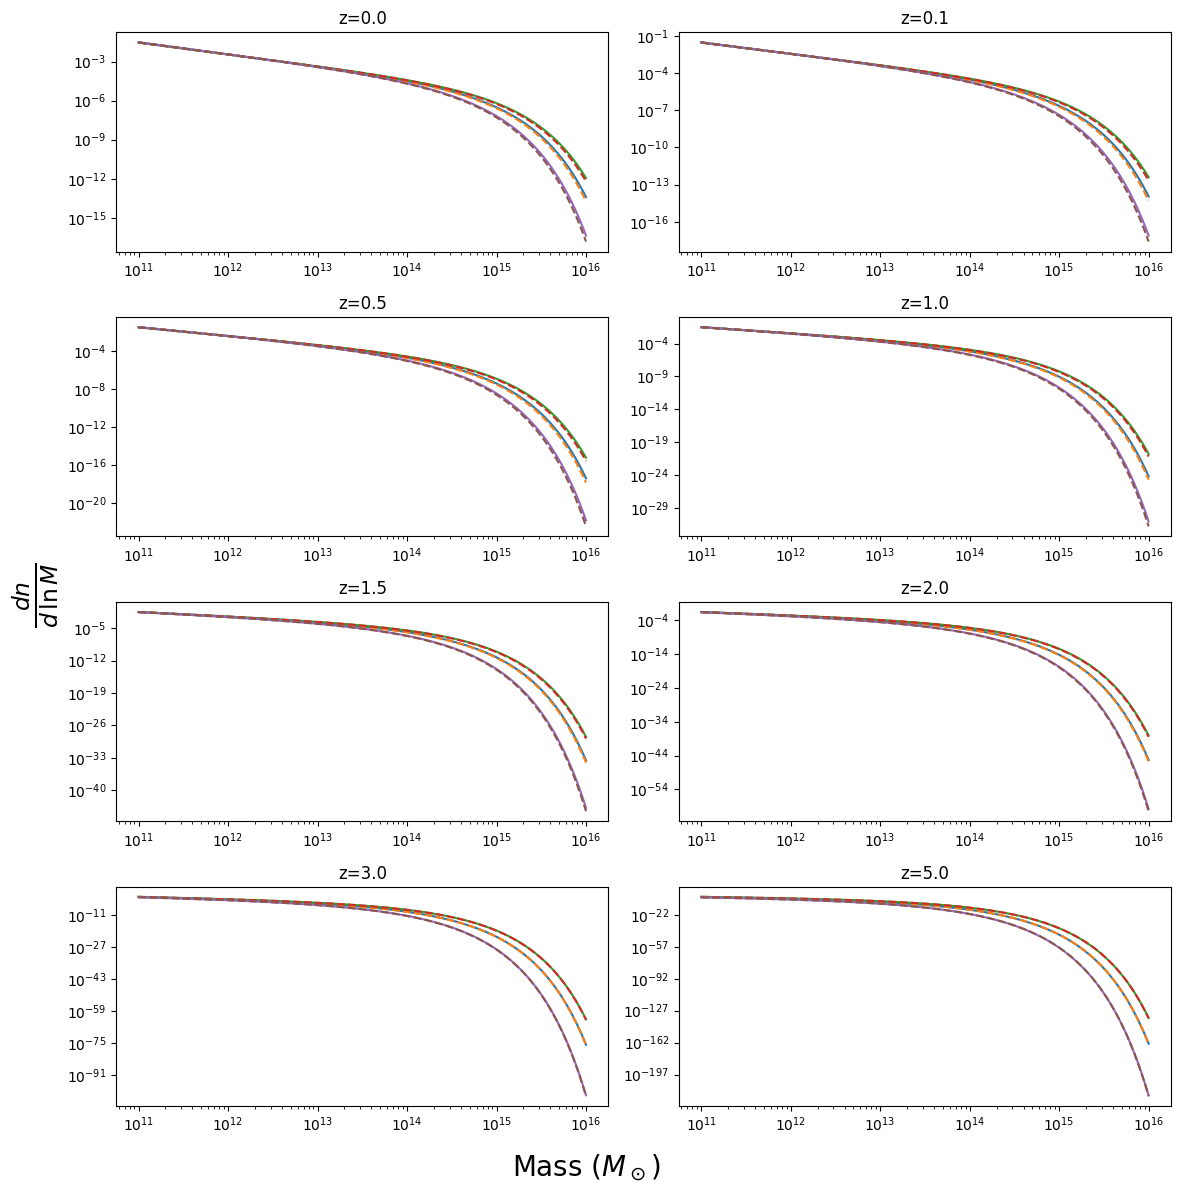

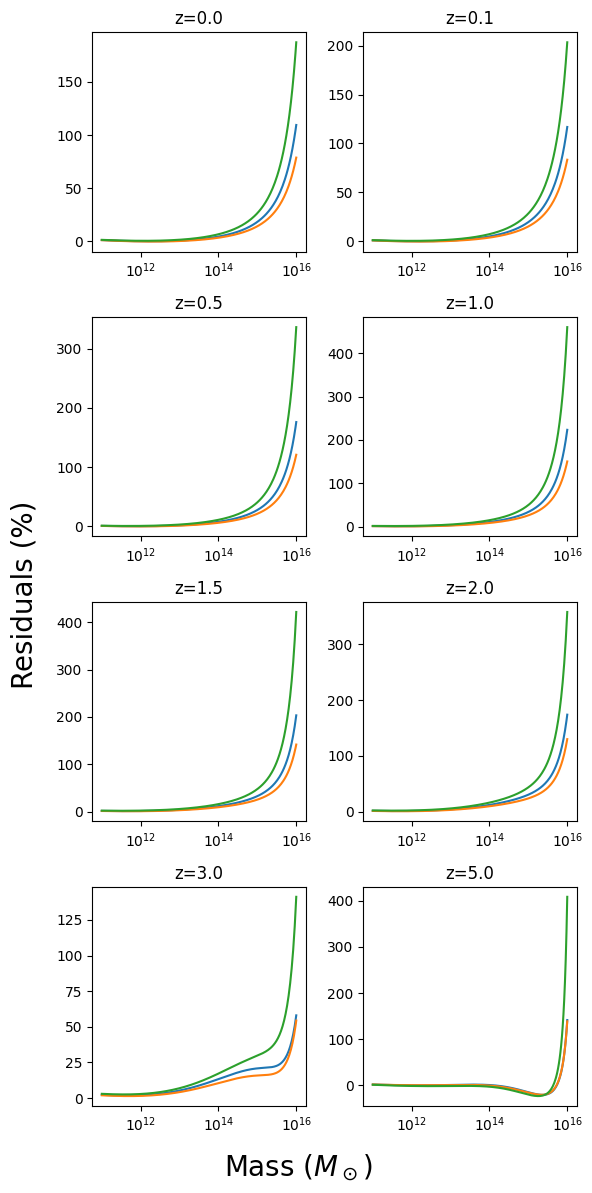

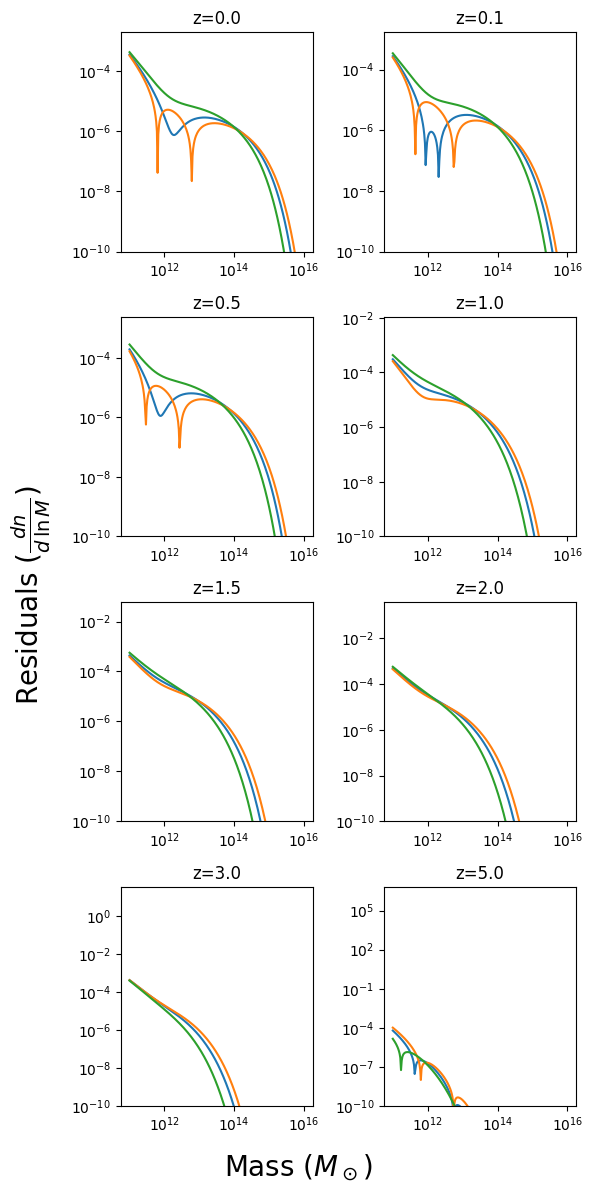

In [4]:
fig, ax = plt.subplots(4, 2, figsize=(12, 12))
x = ax.flatten()

for i in range(len(x)):
    for ii in range(len(cmgs)):
        x[i].plot(Ms, out3[i][ii], ls="-", label="emulated")
        x[i].plot(Ms, out2[i][ii], ls="--", label="true")
    x[i].set_title(f"z={zs[i]}")
    x[i].set_yscale("log")
    x[i].set_xscale("log")

fig.supylabel(r"$\frac{dn}{d\,\ln{M}}$", fontsize=24)
fig.supxlabel(r"Mass $(M_\odot)$", fontsize=20)
fig.set_tight_layout(1)

fig2, ax2 = plt.subplots(4, 2, figsize=(6, 12))
x2 = ax2.flatten()

for i in range(len(x2)):
    for ii in range(len(cmgs)):
        x2[i].plot(Ms, (out3[i][ii] / out2[i][ii] - 1) * 100, label="")
    x2[i].set_title(f"z={zs[i]}")
    x2[i].set_yscale("linear")
    x2[i].set_xscale("log")

fig2.supylabel(r"Residuals (%)", fontsize=20)
fig2.supxlabel(r"Mass $(M_\odot)$", fontsize=20)
fig2.set_tight_layout(1)

fig3, ax3 = plt.subplots(4, 2, figsize=(6, 12))
x3 = ax3.flatten()

for i in range(len(x3)):
    for ii in range(len(cmgs)):
        x3[i].plot(Ms, jnp.abs(out3[i][ii] - out2[i][ii]), label="")
    x3[i].set_title(f"z={zs[i]}")
    x3[i].set_yscale("log")
    x3[i].set_xscale("log")
    x3[i].set_ylim(bottom=10**-10)

fig3.supylabel(r"Residuals ($\frac{dn}{d\,\ln{M}}$)", fontsize=20)
fig3.supxlabel(r"Mass $(M_\odot)$", fontsize=20)
fig3.set_tight_layout(1)
#fig.legend()

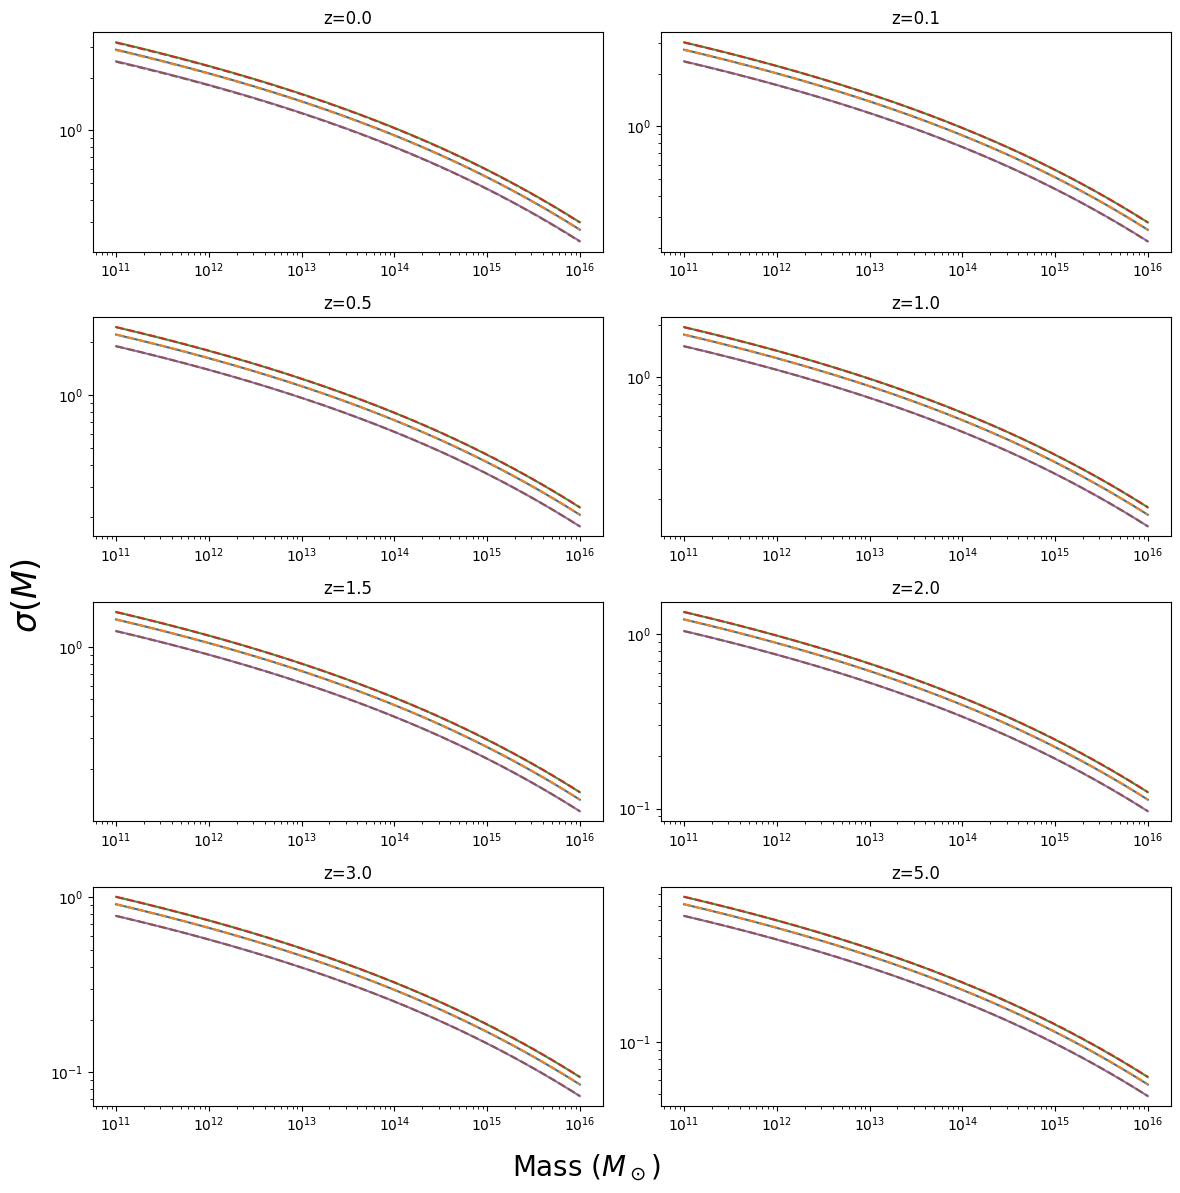

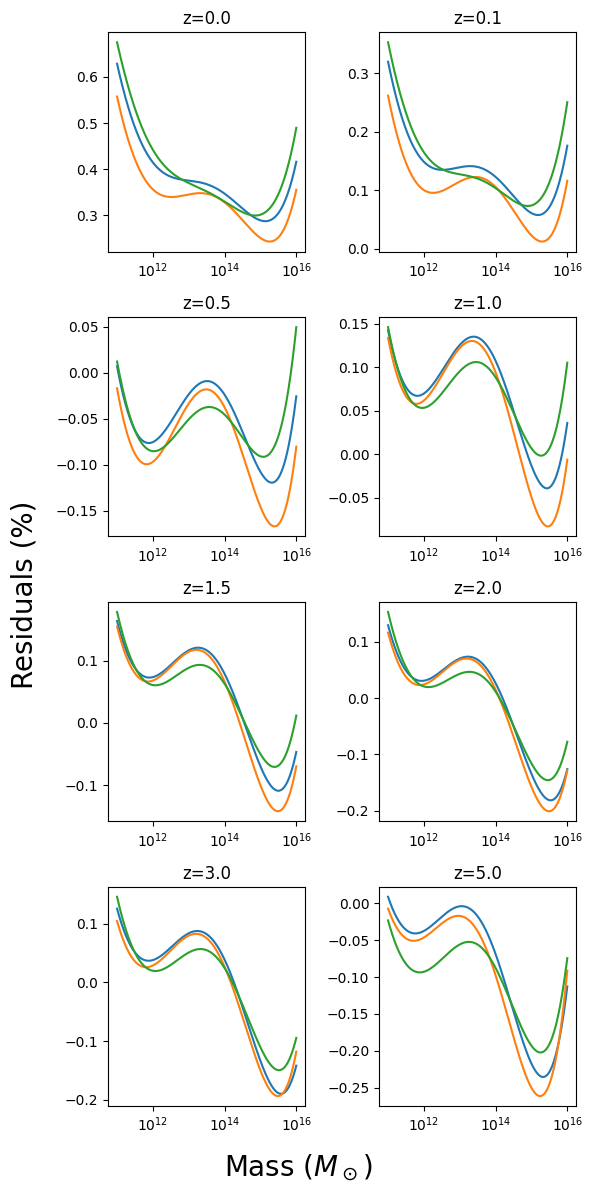

In [5]:
fig, ax = plt.subplots(4, 2, figsize=(12, 12))
x = ax.flatten()

for i in range(len(x)):
    for ii in range(len(cmgs)):
        x[i].plot(Ms, e_sig[i][ii], ls="-", label="emulated")
        x[i].plot(Ms, n_sig[i][ii], ls="--", label="true")
    x[i].set_title(f"z={zs[i]}")
    x[i].set_yscale("log")
    x[i].set_xscale("log")

fig.supylabel(r"$\sigma(M)$", fontsize=24)
fig.supxlabel(r"Mass $(M_\odot)$", fontsize=20)
fig.set_tight_layout(1)

fig2, ax2 = plt.subplots(4, 2, figsize=(6, 12))
x2 = ax2.flatten()

for i in range(len(x2)):
    for ii in range(len(cmgs)):
        x2[i].plot(Ms, (e_sig[i][ii] / n_sig[i][ii] - 1) * 100, label="")
    x2[i].set_title(f"z={zs[i]}")
    x2[i].set_yscale("linear")
    x2[i].set_xscale("log")

fig2.supylabel(r"Residuals (%)", fontsize=20)
fig2.supxlabel(r"Mass $(M_\odot)$", fontsize=20)
fig2.set_tight_layout(1)